# Programa Ejemplo para realizar el entrenamiento de las redes neuronales profundas a partir de distintos esquemas de optimización

## Etapa 1: Definición de los datos.


Antes de comenzar definimos la base de datos de interés. Para este caso particular, usaremos una base de datos sintética con dos atributos y que configura un problema de clasificación con 2 clases ([Ver enlace](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html))

Se cargan las librerías necesarias

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from keras.utils import plot_model
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import numpy as np

Se definen algunas funciones para graficar los datos y las fronteras de decisión

In [2]:
def plot_dataset(X, y, axes):
    plt.figure(figsize=(4, 3), dpi=160)
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "b+")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "r+")
    plt.axis(axes)
    plt.xlabel(r"$x_1$", fontsize=20)
    plt.ylabel(r"$x_2$", fontsize=20, rotation=0)


def plot_predictions(X, y, model, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X_ = np.c_[x0.ravel(), x1.ravel()]
    y_pred = model.predict(X_).reshape(x0.shape)
    plot_dataset(X, y, axes)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.coolwarm, alpha=0.2)

Se crea la base de datos y se divide en los conjuntos de entrenamiento y prueba. Se definen 500 muestras de las cuales el 80% se usa en el entrenamiento y el 20% restante para el conjunto de prueba.

In [3]:
n = 300
X, y = make_moons(n_samples=n, noise=0.18, random_state=42)
train_size = int(n * 0.8)

x_train, x_test = X[:train_size,:], X[train_size:,:]
y_train, y_test = y[:train_size], y[train_size:]

In [4]:
print(x_train.shape)

(240, 2)


Se grafica el conjunto de entrenamiento.


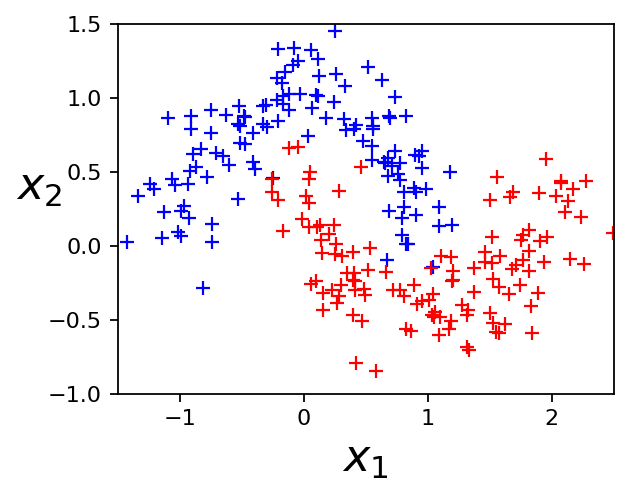

In [7]:
plot_dataset(x_train, y_train, [-1.5, 2.5, -1, 1.5])
plt.show()

Ahora escribiremos algunas funciones que nos serán útiles para definir y entrenar el modelo de redes neuronales. El proceso de entrenamiento se llevará a cabo a partir de tres optimizadores:
- Gradiente descendente sin momentum.
- Gradiente descendente con momentum.
- ADAM.

In [8]:
# Esta función permite definir y entrenar una red neuronal. El argumento de entrada
# es la cantidad de datos que se usa para calcular las derivadas necesarias para
# la optimización.
def fit_model(batch_size, optimizer):
    # Se define una red con dos capas ocultas con 5 y 2 unidades respectivamente
    # y una capa de salida con una única unidad.
    model = Sequential([
        Dense(5, input_dim=2, activation="relu"),
        Dense(2, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    # Se compila el modelo usando el tipo de optimizador elegido.
    if optimizer == 'GD':
      # Optimizador basado en gradiente descendente sin momentum.
      model.compile(
          optimizer=tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.0), # Changed momentum to a float value 0.0
          loss="binary_crossentropy",
          metrics=["accuracy"]
      )
    elif optimizer == 'GD_M':
      # Optimizador basado en gradiente descendente con momentum.
      model.compile(
          optimizer=tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
          loss="binary_crossentropy",
          metrics=["accuracy"]
      )
    elif optimizer == 'ADAM':
      # Optimizador ADAM (Momentum adaptativo).
      model.compile(
          optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999),
          loss="binary_crossentropy",
          metrics=["accuracy"]
      )


    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_test, y_test),
        epochs=2000,
        batch_size=batch_size,
        verbose = 0
    )

    return model, history


def evaluate(model, history):
    # Se evalúa el accuracy del modelo tanto en el conjunto de entrenamiento como
    # en el de prueba.
    _, train_accuracy = model.evaluate(x_train, y_train)
    _, test_accuracy = model.evaluate(x_test, y_test)

    print(f"Trainining accuracy: {train_accuracy:.2f}")
    print(f"Testing accuracy: {test_accuracy:.2f}")

    # Se grafica la función de costo para los conjuntos de entrenamiento y
    # prueba.
    plt.figure(figsize=(4, 3), dpi=160)

    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="test")
    plt.legend()
    plt.show()

## Etapa 2: Gradiente descendente sin momentum.


In [9]:
# Se mide el tiempo de ejecución
%%timeit -n 1 -r 1

model, history = fit_model(batch_size=64, optimizer='GD')
evaluate(model, history)
plot_predictions(x_test, y_test, model, [-1.5, 2.5, -1, 1.5])

UsageError: Line magic function `%%timeit` not found.


## Etapa 3: Gradiente descendente con momentum.

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.8973 - loss: 0.2785
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.8368 - loss: 0.3035
Trainining accuracy: 0.89
Testing accuracy: 0.83


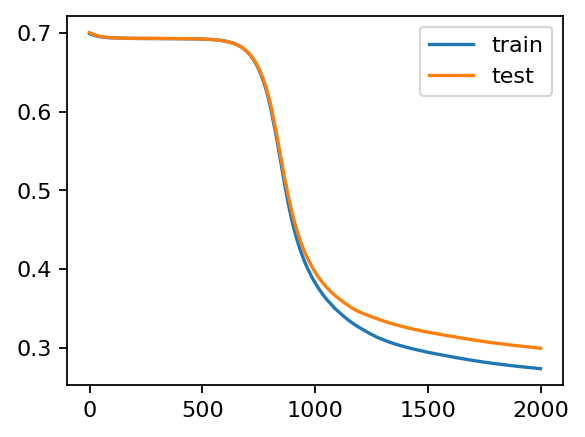

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
2min 11s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


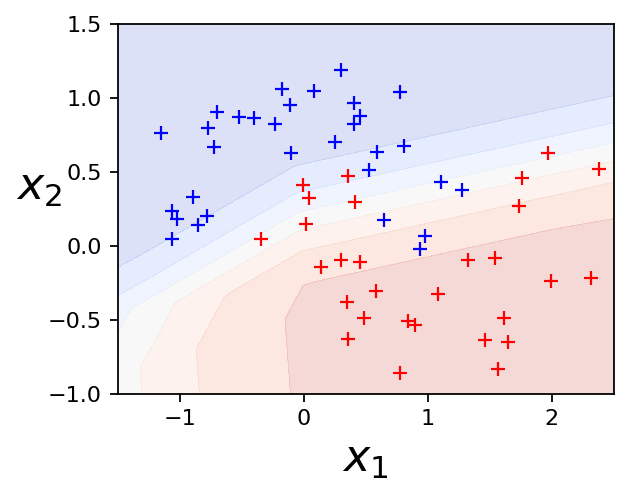

In [17]:
# Se mide el tiempo de ejecución
%%timeit -n 1 -r 1

model, history = fit_model(batch_size=64, optimizer='GD_M')
evaluate(model, history)
plot_predictions(x_test, y_test, model, [-1.5, 2.5, -1, 1.5])

## Etapa 4: ADAM.

d:\OneDrive - Grupo EPM\8. UNIVERSIDAD JAVERIANA\Deep Learning\Caps\Actividades\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8875 - loss: 0.2358 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8333 - loss: 0.2712
Trainining accuracy: 0.89
Testing accuracy: 0.83


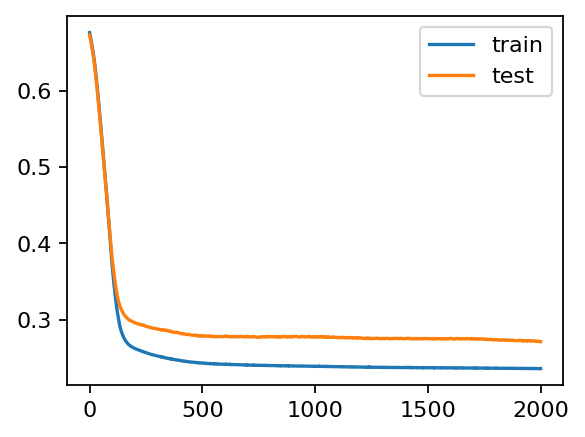

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 493us/step
2min 14s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


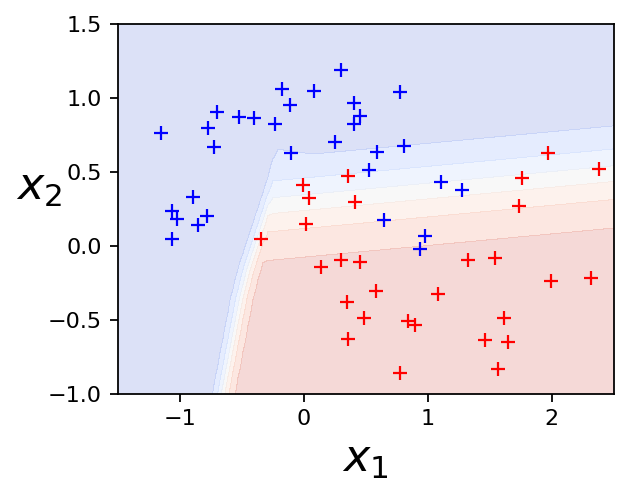

In [10]:
%%timeit -n 1 -r 1

model, history = fit_model(batch_size=64, optimizer='ADAM')
evaluate(model, history)
plot_predictions(x_test, y_test, model, [-1.5, 2.5, -1, 1.5])